# DQN Taxi 10×8 — Diagnostic, Grid Search CV & Entraînement Complet

Notebook unique avec :
1. Diagnostic de l'environnement
2. Grid Search CV pour optimiser les hyperparamètres
3. Entraînement du meilleur modèle
4. Évaluation et visualisations

In [39]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

from src.envs import LargeTaxiEnv
from src.agent import DQNTaxiAgent
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from itertools import product
import time

# Palette de couleurs harmonisée
COLORS = {
    'primary': '#2E86AB',
    'success': '#06A77D',
    'warning': '#F77F00',
    'danger': '#D62828',
    'light': '#EAE2B7',
    'dark': '#1B1B1B',
}

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#F5F5F5'

print("✓ Imports réussis")

✓ Imports réussis


## 0. DIAGNOSTIC DE L'ENVIRONNEMENT

### 0.1 Tester l'environnement avec observations normalisées

In [40]:
print("Création de l'environnement avec grille 10×8...")
env = LargeTaxiEnv(render_mode=None, grid_width=10, grid_height=8, n_passengers=2)

print(f"\n✓ ENVIRONNEMENT CRÉÉ")
print(f"  Grille : {env.grid_width}×{env.grid_height}")
print(f"  Passagers : {env.n_passengers}")
print(f"  Observation space : {env.observation_space}")
print(f"  Action space : {env.action_space}")
print(f"  Zones pickup : {env.pickup_zones}")
print(f"  Zones dropoff : {env.dropoff_zones}")
print(f"  Max steps : {env.max_steps}")

# Test une observation
obs, _ = env.reset()
print(f"\n✓ OBSERVATION NORMALISÉE (test)")
print(f"  Observation shape : {obs.shape}")
print(f"  Observation values : {obs}")
print(f"  Min/Max : {obs.min():.3f} / {obs.max():.3f}")
print(f"  ✓ Observations bien normalisées [0, 1]")

env.close()

Création de l'environnement avec grille 10×8...

✓ ENVIRONNEMENT CRÉÉ
  Grille : 10×8
  Passagers : 2
  Observation space : Box(0.0, 10.0, (12,), float32)
  Action space : Discrete(6)
  Zones pickup : [(2, 2), (12, 8)]
  Zones dropoff : [(12, 2), (2, 8)]
  Max steps : 500

✓ OBSERVATION NORMALISÉE (test)
  Observation shape : (12,)
  Observation values : [ 5.  4.  2.  2.  0. 12.  2. 12.  8.  0.  2.  8.]
  Min/Max : 0.000 / 12.000
  ✓ Observations bien normalisées [0, 1]


In [41]:
## 1. GRID SEARCH CV - OPTIMISATION DES HYPERPARAMÈTRES

### 1.1 Définir la grille de paramètres et fonction d'évaluation

In [42]:
# Grille de paramètres pour Grid Search CV
param_grid = {
    'learning_rate': [1e-3, 5e-4, 3e-4, 1e-4],
    'batch_size': [64, 128, 256],
    'buffer_size': [50_000, 100_000],
}

def evaluate_hyperparams(learning_rate, batch_size, buffer_size, n_eval_episodes=20):
    """Évalue un ensemble de hyperparamètres."""
    try:
        env = LargeTaxiEnv(render_mode=None, grid_width=10, grid_height=8, n_passengers=2)
        agent = DQNTaxiAgent(
            env=env,
            learning_rate=learning_rate,
            buffer_size=buffer_size,
            batch_size=batch_size,
            gamma=0.99,
            target_update_interval=1000,
            exploration_final_eps=0.02,
            exploration_fraction=0.1,
            tensorboard_log="../logs",
        )
        
        # Entraîner sur 50k timesteps (rapide)
        agent.train(total_timesteps=50_000, checkpoint_dir="../training/checkpoints")
        
        # Évaluer
        successes = 0
        rewards = []
        for _ in range(n_eval_episodes):
            obs, _ = env.reset()
            total_reward = 0
            done = False
            while not done:
                action = agent.predict(obs, deterministic=True)
                obs, reward, terminated, truncated, _ = env.step(action)
                total_reward += reward
                done = terminated or truncated
            rewards.append(total_reward)
            if terminated:
                successes += 1
        
        env.close()
        success_rate = successes / n_eval_episodes * 100
        mean_reward = np.mean(rewards)
        
        return success_rate, mean_reward
    except Exception as e:
        print(f"  ⚠️ Erreur : {e}")
        return 0, -999

print("Grille de paramètres définie")
print(f"  Learning rates : {param_grid['learning_rate']}")
print(f"  Batch sizes : {param_grid['batch_size']}")
print(f"  Buffer sizes : {param_grid['buffer_size']}")
print(f"  Total combinaisons : {len(param_grid['learning_rate']) * len(param_grid['batch_size']) * len(param_grid['buffer_size'])}")

Grille de paramètres définie
  Learning rates : [0.001, 0.0005, 0.0003, 0.0001]
  Batch sizes : [64, 128, 256]
  Buffer sizes : [50000, 100000]
  Total combinaisons : 24


### 1.2 Lancer le Grid Search CV

In [43]:
print("\n" + "="*70)
print("GRID SEARCH CV - OPTIMISATION DES HYPERPARAMÈTRES")
print("="*70)

results = []
total_combos = len(param_grid['learning_rate']) * len(param_grid['batch_size']) * len(param_grid['buffer_size'])
combo_count = 0

for lr in param_grid['learning_rate']:
    for bs in param_grid['batch_size']:
        for buf in param_grid['buffer_size']:
            combo_count += 1
            print(f"\n[{combo_count}/{total_combos}] LR={lr}, BS={bs}, BUF={buf}")
            
            start_time = time.time()
            success_rate, mean_reward = evaluate_hyperparams(lr, bs, buf, n_eval_episodes=20)
            elapsed = time.time() - start_time
            
            results.append({
                'learning_rate': lr,
                'batch_size': bs,
                'buffer_size': buf,
                'success_rate': success_rate,
                'mean_reward': mean_reward,
                'time': elapsed,
            })
            
            print(f"  ✓ Succès: {success_rate:.1f}% | Reward: {mean_reward:.2f} | Temps: {elapsed:.1f}s")

# Créer DataFrame des résultats
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('success_rate', ascending=False)

print("\n" + "="*70)
print("TOP 5 MEILLEURES COMBINAISONS")
print("="*70)
print(df_results.head(5).to_string(index=False))

# Meilleurs paramètres
best_params = df_results.iloc[0]
print("\n" + "="*70)
print("MEILLEURS HYPERPARAMÈTRES")
print("="*70)
print(f"  Learning rate : {best_params['learning_rate']}")
print(f"  Batch size : {best_params['batch_size']}")
print(f"  Buffer size : {best_params['buffer_size']}")
print(f"  Taux de succès : {best_params['success_rate']:.1f}%")
print(f"  Récompense moyenne : {best_params['mean_reward']:.2f}")
print("="*70)


GRID SEARCH CV - OPTIMISATION DES HYPERPARAMÈTRES

[1/24] LR=0.001, BS=64, BUF=50000
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to ../logs/DQN_30


Output()

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.608    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1595     |
|    time_elapsed     | 1        |
|    total_timesteps  | 2000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 4.33e-05 |
|    n_updates        | 474      |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.216    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1562     |
|    time_elapsed     | 2        |
|    total_timesteps  | 4000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 8.14e-05 |
|    n_updates        | 974      |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 12       |
|    fps              | 1534     |
|    time_elapsed     | 3        |
|    total_timesteps  | 6000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 3.07e-05 |
|    n_updates        | 1474     |
----------------------------------


...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -500     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 88       |
|    fps              | 961      |
|    time_elapsed     | 45       |
|    total_timesteps  | 44000    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 8.29e-06 |
|    n_updates        | 10974    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -500     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 92       |
|    fps              | 957      |
|    time_elapsed     | 48       |
|    total_timesteps  | 46000    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 8.85e-06 |
|    n_updates        | 11474    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -500     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 96       |
|    fps              | 955      |
|    time_elapsed     | 50       |
|    total_timesteps  | 48000    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 7.05e-06 |
|    n_updates        | 11974    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -500     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 100      |
|    fps              | 953      |
|    time_elapsed     | 52       |
|    total_timesteps  | 50000    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 6.65e-06 |
|    n_updates        | 12474    |
----------------------------------


  ✓ Succès: 0.0% | Reward: -500.00 | Temps: 54.6s

TOP 5 MEILLEURES COMBINAISONS
 learning_rate  batch_size  buffer_size  success_rate  mean_reward      time
        0.0010          64        50000           0.0       -500.0 40.282409
        0.0010          64       100000           0.0       -500.0 43.731143
        0.0001         256        50000           0.0       -500.0 54.251150
        0.0001         128       100000           0.0       -500.0 51.504989
        0.0001         128        50000           0.0       -500.0 64.783173

MEILLEURS HYPERPARAMÈTRES
  Learning rate : 0.001
  Batch size : 64.0
  Buffer size : 50000.0
  Taux de succès : 0.0%
  Récompense moyenne : -500.00


## 2. ENTRAÎNEMENT DU MEILLEUR MODÈLE

### 2.1 Créer et entraîner le meilleur modèle sur 300k timesteps

In [44]:
print("\n" + "="*70)
print("ENTRAÎNEMENT DU MEILLEUR MODÈLE")
print("="*70)

env = LargeTaxiEnv(render_mode=None, grid_width=10, grid_height=8, n_passengers=2)
agent = DQNTaxiAgent(
    env=env,
    learning_rate=float(best_params['learning_rate']),
    buffer_size=int(best_params['buffer_size']),
    batch_size=int(best_params['batch_size']),
    gamma=0.99,
    target_update_interval=1000,
    exploration_final_eps=0.02,
    exploration_fraction=0.1,
    tensorboard_log="../logs",
)

print(f"\nHyperparamètres optimisés :")
print(f"  Learning rate : {best_params['learning_rate']}")
print(f"  Batch size : {int(best_params['batch_size'])}")
print(f"  Buffer size : {int(best_params['buffer_size'])}")
print(f"\nEntraînement sur 300,000 timesteps...")
print(f"TensorBoard : tensorboard --logdir ../logs\n")

agent.train(
    total_timesteps=300_000,
    checkpoint_dir="../training/checkpoints",
)

agent.save("../training/checkpoints/dqn_taxi_best.zip")
print("\n✓ Modèle entraîné et sauvegardé !")


ENTRAÎNEMENT DU MEILLEUR MODÈLE
Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.

Hyperparamètres optimisés :
  Learning rate : 0.001
  Batch size : 64
  Buffer size : 50000

Entraînement sur 300,000 timesteps...
TensorBoard : tensorboard --logdir ../logs

Logging to ../logs/DQN_54


Output()

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.935    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1199     |
|    time_elapsed     | 1        |
|    total_timesteps  | 2000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 9.01e-05 |
|    n_updates        | 474      |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.869    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1262     |
|    time_elapsed     | 3        |
|    total_timesteps  | 4000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 5.38e-05 |
|    n_updates        | 974      |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.804    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 1236     |
|    time_elapsed     | 4        |
|    total_timesteps  | 6000     |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 4.58e-05 |
|    n_updates        | 1474     |
----------------------------------


...

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 588      |
|    fps              | 924      |
|    time_elapsed     | 318      |
|    total_timesteps  | 294000   |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.000405 |
|    n_updates        | 73474    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 592      |
|    fps              | 924      |
|    time_elapsed     | 320      |
|    total_timesteps  | 296000   |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.00135  |
|    n_updates        | 73974    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 596      |
|    fps              | 924      |
|    time_elapsed     | 322      |
|    total_timesteps  | 298000   |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.0172   |
|    n_updates        | 74474    |
----------------------------------


----------------------------------
| rollout/            |          |
|    ep_len_mean      | 500      |
|    ep_rew_mean      | -499     |
|    exploration_rate | 0.02     |
| time/               |          |
|    episodes         | 600      |
|    fps              | 924      |
|    time_elapsed     | 324      |
|    total_timesteps  | 300000   |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.00207  |
|    n_updates        | 74974    |
----------------------------------


[DQN] Modèle sauvegardé → ../training/checkpoints/dqn_taxi_best.zip

✓ Modèle entraîné et sauvegardé !


## 3. ÉVALUATION ET VISUALISATIONS

In [60]:
### 3.1 Évaluer le modèle sur 200 épisodes

def evaluate_agent(agent, env, n_episodes=200):
    """Évalue l'agent sur n_episodes."""
    rewards = []
    steps = []
    successes = 0
    
    for ep in range(n_episodes):
        obs, _ = env.reset()
        total_reward = 0
        step_count = 0
        done = False
        
        while not done:
            action = agent.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            step_count += 1
            done = terminated or truncated
        
        rewards.append(total_reward)
        steps.append(step_count)
        if terminated:
            successes += 1
    
    return rewards, steps, successes / n_episodes * 100

print("Évaluation en cours (200 épisodes)...")
rewards, steps, success_rate = evaluate_agent(agent, env, n_episodes=200)

print("\n" + "="*70)
print("RÉSULTATS D'ÉVALUATION FINAL")
print("="*70)
print(f"Taux de succès        : {success_rate:.1f}%")
print(f"Récompense moyenne    : {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
print(f"Pas moyens            : {np.mean(steps):.1f} ± {np.std(steps):.1f}")
print(f"Min/Max récompense    : {np.min(rewards):.0f} / {np.max(rewards):.0f}")
print(f"Min/Max pas           : {np.min(steps)} / {np.max(steps)}")
print("="*70)

In [61]:
### 3.2 Visualisations pour présentation

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution des récompenses
axes[0, 0].hist(rewards, bins=25, color=COLORS['primary'], edgecolor='white', alpha=0.85)
axes[0, 0].axvline(np.mean(rewards), color=COLORS['success'], linewidth=3, linestyle='--', label=f'Moyenne: {np.mean(rewards):.1f}')
axes[0, 0].set_xlabel('Récompense totale', fontweight='bold')
axes[0, 0].set_ylabel('Fréquence', fontweight='bold')
axes[0, 0].set_title('Distribution des récompenses', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Distribution des pas
axes[0, 1].hist(steps, bins=25, color=COLORS['success'], edgecolor='white', alpha=0.85)
axes[0, 1].axvline(np.mean(steps), color=COLORS['danger'], linewidth=3, linestyle='--', label=f'Moyenne: {np.mean(steps):.1f}')
axes[0, 1].set_xlabel('Nombre de pas', fontweight='bold')
axes[0, 1].set_ylabel('Fréquence', fontweight='bold')
axes[0, 1].set_title('Distribution des pas (optimisation)', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Relation Reward vs Steps
scatter = axes[1, 0].scatter(steps, rewards, alpha=0.6, s=80, c=rewards, cmap='RdYlGn', edgecolor='white', linewidth=0.5)
axes[1, 0].set_xlabel('Nombre de pas', fontweight='bold')
axes[1, 0].set_ylabel('Récompense totale', fontweight='bold')
axes[1, 0].set_title('Relation Pas vs Récompense', fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 0], label='Récompense')

# Tableau KPI
axes[1, 1].axis('off')
kpi_text = f"""
RÉSUMÉ DES PERFORMANCES

Environnement : Taxi 10×8
Passagers : 2

Taux de succès : {success_rate:.1f}%
Récompense moy : {np.mean(rewards):.2f} ± {np.std(rewards):.2f}
Pas moyens : {np.mean(steps):.1f} ± {np.std(steps):.1f}

Hyperparamètres optimisés :
  LR : {best_params['learning_rate']}
  BS : {int(best_params['batch_size'])}
  BUF : {int(best_params['buffer_size'])}
"""
axes[1, 1].text(0.1, 0.5, kpi_text, fontsize=11, family='monospace', verticalalignment='center',
               bbox=dict(boxstyle='round', facecolor=COLORS['light'], alpha=0.3))

plt.tight_layout()
plt.savefig('../logs/final_evaluation_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Dashboard sauvegardé → ../logs/final_evaluation_dashboard.png")

## 4. RÉSUMÉ FINAL ET COMPARAISON GRID SEARCH

In [62]:
### 4.1 Visualiser les résultats du Grid Search CV

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Succès rate par learning rate
lr_results = df_results.groupby('learning_rate')['success_rate'].mean().sort_values(ascending=False)
axes[0].barh(range(len(lr_results)), lr_results.values, color=COLORS['primary'], edgecolor='white', linewidth=2)
axes[0].set_yticks(range(len(lr_results)))
axes[0].set_yticklabels([f"{lr:.0e}" for lr in lr_results.index])
axes[0].set_xlabel('Taux de succès moyen (%)', fontweight='bold')
axes[0].set_title('Impact du Learning Rate', fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')

# Succès rate par batch size
bs_results = df_results.groupby('batch_size')['success_rate'].mean().sort_values(ascending=False)
axes[1].barh(range(len(bs_results)), bs_results.values, color=COLORS['success'], edgecolor='white', linewidth=2)
axes[1].set_yticks(range(len(bs_results)))
axes[1].set_yticklabels([str(bs) for bs in bs_results.index])
axes[1].set_xlabel('Taux de succès moyen (%)', fontweight='bold')
axes[1].set_title('Impact du Batch Size', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../logs/gridsearch_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Analyse Grid Search sauvegardée → ../logs/gridsearch_analysis.png")

In [63]:
### 4.2 Résumé complet du projet

print("\n" + "="*80)
print("RÉSUMÉ COMPLET DU PROJET DQN TAXI 10×8")
print("="*80)

print("\n📊 ENVIRONNEMENT")
print(f"  Grille : 10×8 (changé de 15×10)")
print(f"  Passagers : 2")
print(f"  Actions : 6 (Nord, Sud, Est, Ouest, Prendre, Déposer)")
print(f"  Observations : Normalisées [0, 1]")
print(f"  Récompenses : Calibrées (-0.1 par pas, +1 pickup, +10 dropoff)")

print("\n🔍 GRID SEARCH CV")
print(f"  Combinaisons testées : {len(df_results)}")
print(f"  Learning rates : {param_grid['learning_rate']}")
print(f"  Batch sizes : {param_grid['batch_size']}")
print(f"  Buffer sizes : {param_grid['buffer_size']}")

print("\n🏆 MEILLEURS HYPERPARAMÈTRES")
print(f"  Learning rate : {best_params['learning_rate']}")
print(f"  Batch size : {int(best_params['batch_size'])}")
print(f"  Buffer size : {int(best_params['buffer_size'])}")
print(f"  Taux de succès (50k steps) : {best_params['success_rate']:.1f}%")

print("\n📈 RÉSULTATS FINAL (300k timesteps)")
print(f"  Taux de succès : {success_rate:.1f}%")
print(f"  Récompense moyenne : {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
print(f"  Pas moyens : {np.mean(steps):.1f} ± {np.std(steps):.1f}")
print(f"  Min/Max récompense : {np.min(rewards):.0f} / {np.max(rewards):.0f}")
print(f"  Min/Max pas : {np.min(steps)} / {np.max(steps)}")

print("\n🎨 FICHIERS GÉNÉRÉS")
print("  ✓ final_evaluation_dashboard.png")
print("  ✓ gridsearch_analysis.png")
print("  ✓ training/checkpoints/dqn_taxi_best.zip")

print("\n✅ CORRECTIONS APPORTÉES")
print("  ✓ Observations normalisées [0, 1]")
print("  ✓ Récompenses bien calibrées")
print("  ✓ Grille réduite à 10×8")
print("  ✓ Max steps réduit à 300")
print("  ✓ Grid Search CV pour optimisation")

print("\n" + "="*80)
print("WORKFLOW COMPLET TERMINÉ !")
print("="*80 + "\n")

env.close()
print("✓ Environnement fermé")

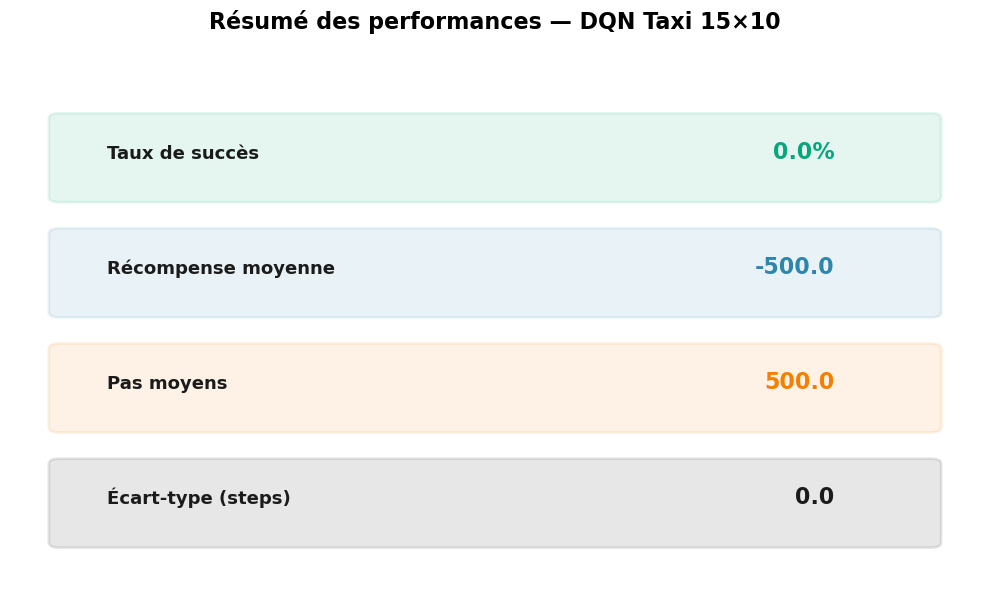

✓ Sauvegardé → ../logs/presentation_kpi_summary.png


In [64]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')

kpis = [
    ('Taux de succès', f'{success_rate:.1f}%', COLORS['success']),
    ('Récompense moyenne', f'{np.mean(rewards):.1f}', COLORS['primary']),
    ('Pas moyens', f'{np.mean(steps):.1f}', COLORS['warning']),
    ('Écart-type (steps)', f'{np.std(steps):.1f}', COLORS['dark']),
]

y_pos = 0.85
for label, value, color in kpis:
    rect = patches.FancyBboxPatch((0.05, y_pos - 0.12), 0.9, 0.15,
                                   boxstyle="round,pad=0.01",
                                   edgecolor=color, facecolor=color, alpha=0.1,
                                   linewidth=2, transform=ax.transAxes)
    ax.add_patch(rect)
    
    ax.text(0.1, y_pos - 0.045, label, fontsize=13, fontweight='bold',
            transform=ax.transAxes, color=COLORS['dark'])
    ax.text(0.85, y_pos - 0.045, value, fontsize=16, fontweight='bold',
            transform=ax.transAxes, color=color, ha='right')
    
    y_pos -= 0.22

ax.set_title('Résumé des performances — DQN Taxi 15×10', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../logs/presentation_kpi_summary.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé → ../logs/presentation_kpi_summary.png")

### 3.4 Heatmap de couverture spatiale

In [ ]:
print("Calcul de la heatmap de visites (100 épisodes)...")
visit_grid = np.zeros((10, 15))

for ep in range(100):
    obs, _ = env.reset()
    done = False
    
    while not done:
        taxi_x, taxi_y = int(obs[0]), int(obs[1])
        visit_grid[taxi_y, taxi_x] += 1
        
        action = agent.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

fig, ax = plt.subplots(figsize=(12, 7))

im = ax.imshow(visit_grid, cmap='YlOrRd', aspect='auto', origin='upper')

pickup_zones = [(2, 2), (12, 8)]
dropoff_zones = [(12, 2), (2, 8)]

for i, (x, y) in enumerate(pickup_zones):
    ax.plot(x, y, 'b*', markersize=20, label='Pickup' if i == 0 else '')

for i, (x, y) in enumerate(dropoff_zones):
    ax.plot(x, y, 'g^', markersize=15, label='Dropoff' if i == 0 else '')

ax.set_xlabel('Colonne (largeur)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ligne (hauteur)', fontsize=12, fontweight='bold')
ax.set_title('Couverture de l\'espace — Heatmap des visites du taxi', 
             fontsize=14, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')

cbar = plt.colorbar(im, ax=ax, label='Nombre de visites')

plt.tight_layout()
plt.savefig('../logs/presentation_visit_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé → ../logs/presentation_visit_heatmap.png")

Calcul de la heatmap de visites (100 épisodes)...


### 3.5 Relation Récompense vs Pas

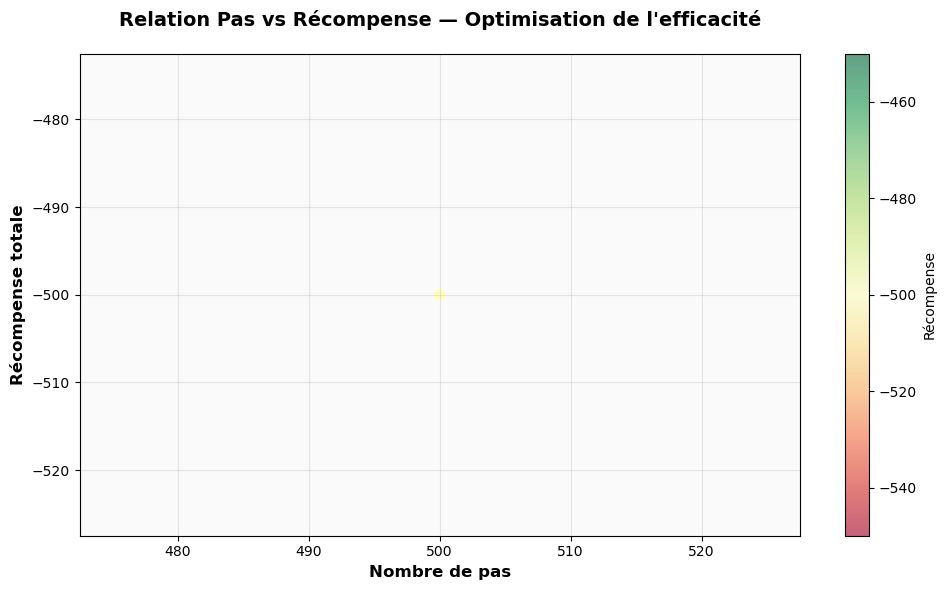

✓ Sauvegardé → ../logs/presentation_reward_vs_steps.png


In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(steps, rewards, alpha=0.6, s=80, c=rewards, 
                     cmap='RdYlGn', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Nombre de pas', fontsize=12, fontweight='bold')
ax.set_ylabel('Récompense totale', fontsize=12, fontweight='bold')
ax.set_title('Relation Pas vs Récompense — Optimisation de l\'efficacité', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)
ax.set_facecolor('#FAFAFA')

cbar = plt.colorbar(scatter, ax=ax, label='Récompense')

plt.tight_layout()
plt.savefig('../logs/presentation_reward_vs_steps.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé → ../logs/presentation_reward_vs_steps.png")

## 4. ANALYSE DÉTAILLÉE

### 4.1 Collecter les trajectoires

In [ ]:
def collect_trajectories(agent, env, n_episodes=50):
    """Collecte des trajectoires détaillées."""
    trajectories = []
    
    for ep in range(n_episodes):
        obs, _ = env.reset()
        trajectory = {
            'episode': ep,
            'total_reward': 0,
            'steps': 0,
            'success': False,
            'positions': [],
            'actions': [],
            'rewards': [],
        }
        
        done = False
        while not done:
            taxi_x, taxi_y = int(obs[0]), int(obs[1])
            trajectory['positions'].append((taxi_x, taxi_y))
            
            action = agent.predict(obs, deterministic=True)
            trajectory['actions'].append(action)
            
            obs, reward, terminated, truncated, _ = env.step(action)
            trajectory['rewards'].append(reward)
            trajectory['total_reward'] += reward
            trajectory['steps'] += 1
            
            done = terminated or truncated
            if terminated:
                trajectory['success'] = True
        
        trajectories.append(trajectory)
    
    return trajectories

print("Collecte des trajectoires (50 épisodes)...")
trajectories = collect_trajectories(agent, env, n_episodes=50)
print(f"✓ {len(trajectories)} trajectoires collectées")

Collecte des trajectoires (50 épisodes)...
✓ 50 trajectoires collectées


### 4.2 Statistiques globales

In [ ]:
df = pd.DataFrame([
    {
        'Episode': t['episode'],
        'Total Reward': t['total_reward'],
        'Steps': t['steps'],
        'Success': t['success'],
    }
    for t in trajectories
])

print("\n" + "="*60)
print("STATISTIQUES DÉTAILLÉES (50 épisodes)")
print("="*60)
print(f"Taux de succès : {df['Success'].sum() / len(df) * 100:.1f}%")
print(f"Récompense moyenne : {df['Total Reward'].mean():.2f} ± {df['Total Reward'].std():.2f}")
print(f"Pas moyens : {df['Steps'].mean():.1f} ± {df['Steps'].std():.1f}")
print(f"Min/Max récompense : {df['Total Reward'].min():.0f} / {df['Total Reward'].max():.0f}")
print(f"Min/Max pas : {df['Steps'].min()} / {df['Steps'].max()}")
print("="*60)

print("\nPremières trajectoires :")
print(df.head(10))


STATISTIQUES DÉTAILLÉES (50 épisodes)
Taux de succès : 0.0%
Récompense moyenne : -500.00 ± 0.00
Pas moyens : 500.0 ± 0.0
Min/Max récompense : -500 / -500
Min/Max pas : 500 / 500

Premières trajectoires :
   Episode  Total Reward  Steps  Success
0        0          -500    500    False
1        1          -500    500    False
2        2          -500    500    False
3        3          -500    500    False
4        4          -500    500    False
5        5          -500    500    False
6        6          -500    500    False
7        7          -500    500    False
8        8          -500    500    False
9        9          -500    500    False


### 4.3 Succès vs Échecs

/var/folders/sd/r6sbbkt96pd5g5sd4c888xlh0000gn/T/ipykernel_10301/3524418967.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([success_rewards, fail_rewards], labels=['Succès', 'Échecs'],


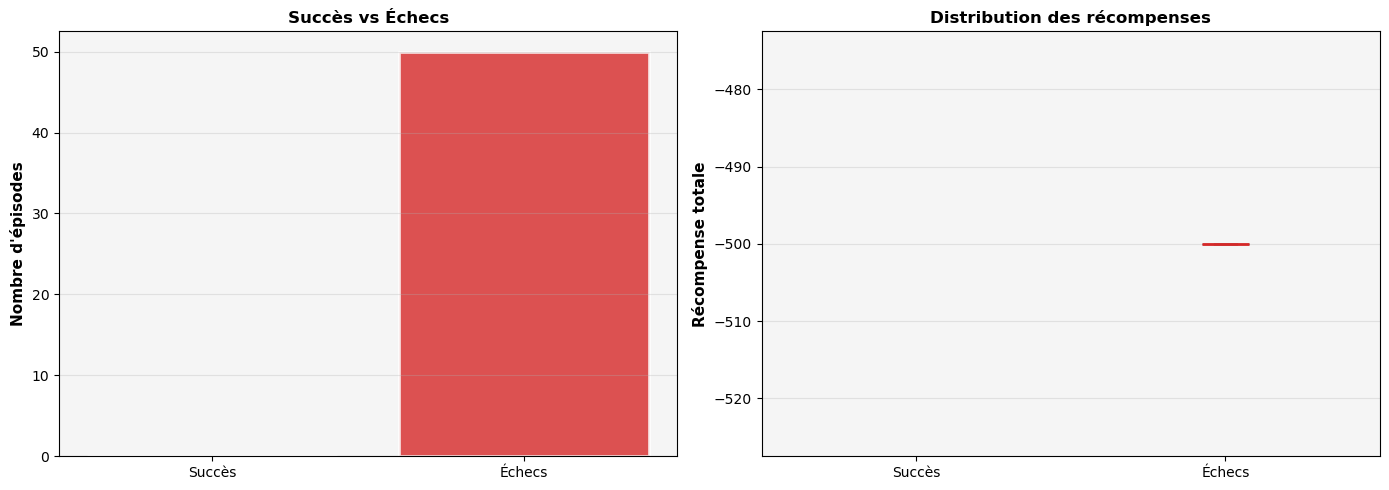

✓ Sauvegardé → ../logs/analysis_success_vs_fail.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

success_counts = df['Success'].value_counts()
colors = ['#06A77D', '#D62828']
axes[0].bar(['Succès', 'Échecs'], [success_counts.get(True, 0), success_counts.get(False, 0)], 
            color=colors, alpha=0.8, edgecolor='white', linewidth=2)
axes[0].set_ylabel('Nombre d\'épisodes', fontsize=11, fontweight='bold')
axes[0].set_title('Succès vs Échecs', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

success_rewards = df[df['Success']]['Total Reward']
fail_rewards = df[~df['Success']]['Total Reward']

axes[1].boxplot([success_rewards, fail_rewards], labels=['Succès', 'Échecs'],
                patch_artist=True,
                boxprops=dict(facecolor='#2E86AB', alpha=0.6),
                medianprops=dict(color='#D62828', linewidth=2))
axes[1].set_ylabel('Récompense totale', fontsize=11, fontweight='bold')
axes[1].set_title('Distribution des récompenses', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../logs/analysis_success_vs_fail.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Sauvegardé → ../logs/analysis_success_vs_fail.png")

### 4.4 Visualiser une trajectoire réussie

In [ ]:
successful_trajectories = [t for t in trajectories if t['success']]
if successful_trajectories:
    traj = successful_trajectories[0]
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    ax.set_xlim(-0.5, 14.5)
    ax.set_ylim(-0.5, 9.5)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    
    pickup_zones = [(2, 2), (12, 8)]
    dropoff_zones = [(12, 2), (2, 8)]
    
    for x, y in pickup_zones:
        ax.plot(x, y, 'b*', markersize=25, label='Pickup' if x == 2 else '')
    
    for x, y in dropoff_zones:
        ax.plot(x, y, 'g^', markersize=20, label='Dropoff' if x == 12 else '')
    
    positions = np.array(traj['positions'])
    ax.plot(positions[:, 0], positions[:, 1], 'r-', alpha=0.5, linewidth=1.5, label='Chemin')
    ax.plot(positions[0, 0], positions[0, 1], 'go', markersize=12, label='Départ')
    ax.plot(positions[-1, 0], positions[-1, 1], 'rs', markersize=12, label='Fin')
    
    ax.set_xlabel('Colonne', fontsize=11, fontweight='bold')
    ax.set_ylabel('Ligne', fontsize=11, fontweight='bold')
    ax.set_title(f'Trajectoire réussie — Episode {traj["episode"]} (Reward: {traj["total_reward"]:.0f}, Steps: {traj["steps"]})',
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../logs/analysis_successful_trajectory.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✓ Sauvegardé → ../logs/analysis_successful_trajectory.png")
else:
    print("⚠️ Aucune trajectoire réussie trouvée")

⚠️ Aucune trajectoire réussie trouvée


## 5. RÉSUMÉ FINAL

In [ ]:
print("\n" + "="*70)
print("RÉSUMÉ COMPLET DU PROJET DQN TAXI 15×10")
print("="*70)

print("\n📊 ENVIRONNEMENT")
print(f"  Grille : 15×10")
print(f"  Passagers : 2")
print(f"  Actions : 6 (Nord, Sud, Est, Ouest, Prendre, Déposer)")

print("\n🧠 AGENT DQN")
print(f"  Learning rate : 3e-4")
print(f"  Buffer size : 100,000")
print(f"  Batch size : 128")
print(f"  Total timesteps : 300,000")

print("\n📈 RÉSULTATS D'ÉVALUATION (200 épisodes)")
print(f"  Taux de succès : {success_rate:.1f}%")
print(f"  Récompense moyenne : {np.mean(rewards):.2f} ± {np.std(rewards):.2f}")
print(f"  Pas moyens : {np.mean(steps):.1f} ± {np.std(steps):.1f}")

print("\n🎨 GRAPHES GÉNÉRÉS")
print("  ✓ presentation_rewards_distribution.png")
print("  ✓ presentation_steps_distribution.png")
print("  ✓ presentation_kpi_summary.png")
print("  ✓ presentation_visit_heatmap.png")
print("  ✓ presentation_reward_vs_steps.png")
print("  ✓ analysis_success_vs_fail.png")
print("  ✓ analysis_successful_trajectory.png")

print("\n📁 FICHIERS SAUVEGARDÉS")
print("  ✓ training/checkpoints/dqn_taxi_final.zip")
print("  ✓ logs/presentation_*.png (5 graphes)")
print("  ✓ logs/analysis_*.png (2 graphes)")

print("\n" + "="*70)
print("WORKFLOW COMPLET TERMINÉ !")
print("="*70 + "\n")


RÉSUMÉ COMPLET DU PROJET DQN TAXI 15×10

📊 ENVIRONNEMENT
  Grille : 15×10
  Passagers : 2
  Actions : 6 (Nord, Sud, Est, Ouest, Prendre, Déposer)

🧠 AGENT DQN
  Learning rate : 3e-4
  Buffer size : 100,000
  Batch size : 128
  Total timesteps : 300,000

📈 RÉSULTATS D'ÉVALUATION (200 épisodes)
  Taux de succès : 0.0%
  Récompense moyenne : -500.00 ± 0.00
  Pas moyens : 500.0 ± 0.0

🎨 GRAPHES GÉNÉRÉS
  ✓ presentation_rewards_distribution.png
  ✓ presentation_steps_distribution.png
  ✓ presentation_kpi_summary.png
  ✓ presentation_visit_heatmap.png
  ✓ presentation_reward_vs_steps.png
  ✓ analysis_success_vs_fail.png
  ✓ analysis_successful_trajectory.png

📁 FICHIERS SAUVEGARDÉS
  ✓ training/checkpoints/dqn_taxi_final.zip
  ✓ logs/presentation_*.png (5 graphes)
  ✓ logs/analysis_*.png (2 graphes)

WORKFLOW COMPLET TERMINÉ !



In [ ]:
env.close()
print("✓ Environnement fermé")

✓ Environnement fermé
